# 04 Model Evaluation

En este notebook se realiza la evaluación final del modelo seleccionado durante la fase de entrenamiento.

El modelo seleccionado es XGBoost con los hiperparámetros obtenidos mediante validación cruzada y optimización por Average Precision.

Además, durante la fase de entrenamiento se estableció un threshold de clasificación de aproximadamente 0.315, con el objetivo operativo de alcanzar alrededor de un 75 % de recall y reducir los falsos negativos.

Tanto el modelo como el threshold fueron seleccionados utilizando exclusivamente el conjunto de entrenamiento.

En esta fase se utilizará por primera vez el conjunto de test reservado para estimar la capacidad de generalización de la configuración final.

Los resultados obtenidos sobre test no se utilizarán para modificar el modelo, sus hiperparámetros o el threshold.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

from xgboost import XGBClassifier

## 1. Carga del conjunto de test

Se carga el conjunto de test generado durante la fase de preprocesamiento.

Este conjunto permaneció completamente reservado durante el entrenamiento, la optimización de hiperparámetros, la selección del modelo y la selección del threshold.

In [3]:
PROCESSED_DATA_PATH = "../data/processed"

X_test = pd.read_csv(
    f"{PROCESSED_DATA_PATH}/X_test.csv"
)

y_test = pd.read_csv(
    f"{PROCESSED_DATA_PATH}/y_test.csv"
).squeeze("columns")

In [4]:
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nDistribución de la variable objetivo:")
print(y_test.value_counts())

print("\nProporciones:")
print(y_test.value_counts(normalize=True))

X_test: (1409, 26)
y_test: (1409,)

Distribución de la variable objetivo:
Churn
0    1035
1     374
Name: count, dtype: int64

Proporciones:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


## 2. Modelo final

Durante la fase de entrenamiento, XGBoost fue seleccionado como modelo final por obtener el mayor Average Precision medio en validación cruzada.

La optimización de hiperparámetros seleccionó la siguiente configuración:

- `n_estimators = 500`
- `learning_rate = 0.01`
- `max_depth = 4`
- `min_child_weight = 10`
- `subsample = 0.8`
- `colsample_bytree = 0.7`

Para realizar la evaluación final es necesario ajustar esta configuración utilizando todo el conjunto de entrenamiento y, posteriormente, generar predicciones sobre el conjunto de test.

El threshold establecido durante la fase de entrenamiento se mantiene fijado en aproximadamente 0.315.

In [5]:
X_train = pd.read_csv(
    f"{PROCESSED_DATA_PATH}/X_train.csv"
)

y_train = pd.read_csv(
    f"{PROCESSED_DATA_PATH}/y_train.csv"
).squeeze("columns")

In [6]:
final_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=4,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.7,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

final_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [7]:
selected_threshold = 0.315

## 3. Predicciones sobre el conjunto de test

Una vez entrenado el modelo final utilizando todo el conjunto de entrenamiento, se generan las probabilidades de churn para las observaciones del conjunto de test.

A partir de estas probabilidades se obtienen dos conjuntos de predicciones:

- Predicciones utilizando el threshold por defecto de 0.5.
- Predicciones utilizando el threshold seleccionado durante la fase de entrenamiento (0.315).

La comparación permitirá comprobar si el comportamiento observado durante la selección del threshold se mantiene sobre datos no utilizados durante el desarrollo del modelo.

In [8]:
y_test_proba = final_model.predict_proba(X_test)[:, 1]

y_test_proba[:10]

array([0.03413679, 0.8031764 , 0.07024414, 0.33315423, 0.02099807,
       0.58996856, 0.4678698 , 0.10882049, 0.01358988, 0.3623925 ],
      dtype=float32)

In [9]:
print("Probabilidad mínima:", y_test_proba.min())
print("Probabilidad máxima:", y_test_proba.max())
print("Probabilidad media:", y_test_proba.mean())

Probabilidad mínima: 0.011260365
Probabilidad máxima: 0.9024041
Probabilidad media: 0.265993


### 4.2 Conversion de probabilidades en clases

In [10]:
y_test_pred_default = (
    y_test_proba >= 0.5
).astype(int)

y_test_pred_selected = (
    y_test_proba >= selected_threshold
).astype(int)

In [11]:
prediction_comparison = pd.DataFrame({
    "Threshold 0.5": pd.Series(y_test_pred_default).value_counts(),
    "Threshold 0.315": pd.Series(y_test_pred_selected).value_counts()
})

prediction_comparison.index = ["No Churn", "Churn"]

prediction_comparison

,Threshold 0.5,Threshold 0.315
No Churn,1112,881
Churn,297,528


## 5. Evaluación final

El rendimiento del modelo se evalúa sobre el conjunto de test mediante diferentes métricas de clasificación.

Se incluyen accuracy, precision, recall y F1-score para evaluar las predicciones binarias, junto con ROC-AUC y Average Precision para evaluar la capacidad del modelo para discriminar y priorizar la clase positiva a partir de las probabilidades estimadas.

ROC-AUC y Average Precision son independientes del threshold concreto utilizado para generar las predicciones binarias, por lo que sus valores serán comunes a ambas configuraciones.

In [12]:
test_roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)

test_average_precision = average_precision_score(
    y_test,
    y_test_proba
)

print(f"ROC-AUC:           {test_roc_auc:.4f}")
print(f"Average Precision: {test_average_precision:.4f}")

ROC-AUC:           0.8494
Average Precision: 0.6670


In [13]:
def calculate_classification_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred)
    }

In [14]:
default_metrics = calculate_classification_metrics(
    y_test,
    y_test_pred_default
)

selected_metrics = calculate_classification_metrics(
    y_test,
    y_test_pred_selected
)

In [15]:
test_metrics_comparison = pd.DataFrame({
    "Threshold 0.5": default_metrics,
    f"Threshold {selected_threshold:.3f}": selected_metrics
}).T

test_metrics_comparison

,Accuracy,Precision,Recall,F1
Threshold 0.5,0.804826,0.666667,0.529412,0.590164
Threshold 0.315,0.762952,0.537879,0.759358,0.629712


In [16]:
print(f"ROC-AUC:           {test_roc_auc:.4f}")
print(f"Average Precision: {test_average_precision:.4f}")

ROC-AUC:           0.8494
Average Precision: 0.6670


In [17]:
test_metrics_comparison

,Accuracy,Precision,Recall,F1
Threshold 0.5,0.804826,0.666667,0.529412,0.590164
Threshold 0.315,0.762952,0.537879,0.759358,0.629712


### 5.1 Resultados de la evaluación final

El modelo final obtiene un ROC-AUC de 0.849 y un Average Precision de 0.667 sobre el conjunto de test.

El Average Precision obtenido es muy próximo al observado durante la validación cruzada del modelo seleccionado (aproximadamente 0.669), lo que indica que el rendimiento estimado durante el entrenamiento se mantiene sobre datos no utilizados durante el desarrollo del modelo.

Con el threshold por defecto de 0.5, el modelo obtiene una accuracy de 0.805, una precision de 0.667, un recall de 0.529 y un F1-score de 0.590.

Al aplicar el threshold de aproximadamente 0.315 seleccionado durante la fase de entrenamiento, el recall aumenta hasta 0.759, superando ligeramente el objetivo operativo de aproximadamente 0.75 establecido previamente.

Este incremento del recall implica una reducción de la precision, que pasa de 0.667 a 0.538, y de la accuracy, que disminuye de 0.805 a 0.763. Este comportamiento es coherente con el trade-off esperado al reducir el threshold: se identifican más clientes que realizan churn a cambio de clasificar también un mayor número de clientes que finalmente permanecen como posibles casos de churn.

El F1-score aumenta de 0.590 a 0.630, aunque esta métrica no fue utilizada como criterio para seleccionar el threshold.

En conjunto, los resultados del conjunto de test son consistentes con los obtenidos durante la fase de entrenamiento y muestran que el comportamiento esperado del threshold seleccionado se mantiene sobre datos no utilizados para su elección.

## 6. Matriz de confusión

Para analizar los errores de clasificación se compara la matriz de confusión obtenida con el threshold por defecto de 0.5 y con el threshold seleccionado de aproximadamente 0.315.

Esta comparación permite cuantificar directamente el efecto del cambio de threshold sobre falsos positivos y falsos negativos.

In [18]:
cm_default = confusion_matrix(
    y_test,
    y_test_pred_default
)

cm_selected = confusion_matrix(
    y_test,
    y_test_pred_selected
)

print("Threshold 0.5:")
print(cm_default)

print("\nThreshold seleccionado:")
print(cm_selected)

Threshold 0.5:
[[936  99]
 [176 198]]

Threshold seleccionado:
[[791 244]
 [ 90 284]]


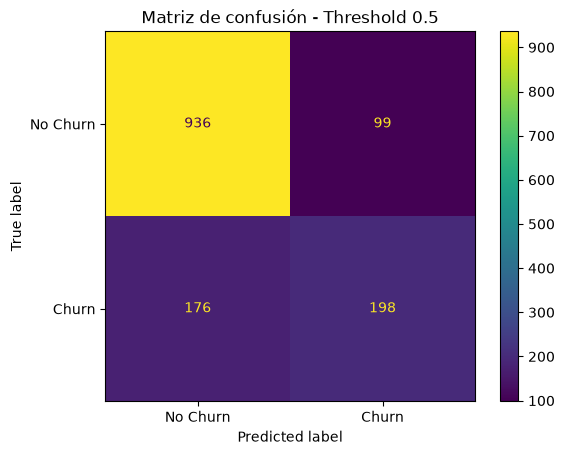

In [19]:
ConfusionMatrixDisplay(
    confusion_matrix=cm_default,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title("Matriz de confusión - Threshold 0.5")
plt.show()

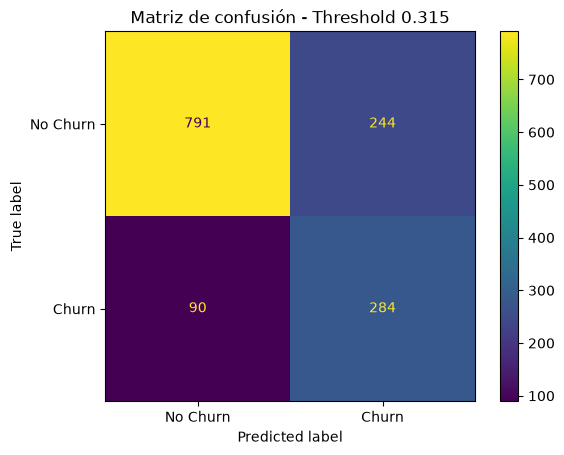

In [20]:
ConfusionMatrixDisplay(
    confusion_matrix=cm_selected,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title(
    f"Matriz de confusión - Threshold {selected_threshold:.3f}"
)
plt.show()

In [21]:
tn_default, fp_default, fn_default, tp_default = cm_default.ravel()
tn_selected, fp_selected, fn_selected, tp_selected = cm_selected.ravel()

confusion_comparison = pd.DataFrame({
    "Threshold 0.5": {
        "True Negatives": tn_default,
        "False Positives": fp_default,
        "False Negatives": fn_default,
        "True Positives": tp_default
    },
    f"Threshold {selected_threshold:.3f}": {
        "True Negatives": tn_selected,
        "False Positives": fp_selected,
        "False Negatives": fn_selected,
        "True Positives": tp_selected
    }
}).T

confusion_comparison

,True Negatives,False Positives,False Negatives,True Positives
Threshold 0.5,936,99,176,198
Threshold 0.315,791,244,90,284


### 6.1 Interpretación de la matriz de confusión

La reducción del threshold de 0.5 a aproximadamente 0.315 modifica de forma significativa el tipo de errores cometidos por el modelo.

Con el threshold por defecto de 0.5, el modelo identifica correctamente 198 de los 374 clientes que realizan churn, mientras que 176 churners no son detectados. Esto corresponde a un recall de aproximadamente 0.529.

Con el threshold seleccionado de aproximadamente 0.315, el número de verdaderos positivos aumenta de 198 a 284 y los falsos negativos se reducen de 176 a 90. Por tanto, el modelo identifica 86 churners adicionales sobre el conjunto de test, alcanzando un recall de aproximadamente 0.759.

Este incremento en la detección de churn tiene como contrapartida un aumento de los falsos positivos, que pasan de 99 a 244. Es decir, 145 clientes adicionales que realmente no realizan churn son clasificados como clientes de riesgo.

Este comportamiento refleja el trade-off esperado al reducir el threshold. Bajo el supuesto de negocio establecido en el proyecto, donde no detectar a un cliente que abandona se considera más costoso que realizar una acción de retención sobre un cliente que finalmente permanece, el threshold seleccionado prioriza la reducción de falsos negativos a costa de incrementar los falsos positivos.

La elección no representa necesariamente el threshold económicamente óptimo, ya que el dataset no proporciona información sobre el coste de las acciones de retención ni sobre el coste económico asociado al churn.

## 7. Evaluación basada en probabilidades

Además de evaluar las predicciones binarias generadas a partir del threshold, se analiza la capacidad del modelo para discriminar entre clientes que realizan churn y clientes que permanecen.

Para ello se utilizan las curvas ROC y Precision-Recall, construidas a partir de las probabilidades estimadas por el modelo.

### 7.1 Curva ROC

La curva ROC representa la relación entre la tasa de verdaderos positivos (True Positive Rate) y la tasa de falsos positivos (False Positive Rate) para diferentes thresholds de clasificación.

El área bajo la curva (ROC-AUC) resume la capacidad del modelo para discriminar entre las clases a lo largo de todos los posibles thresholds.

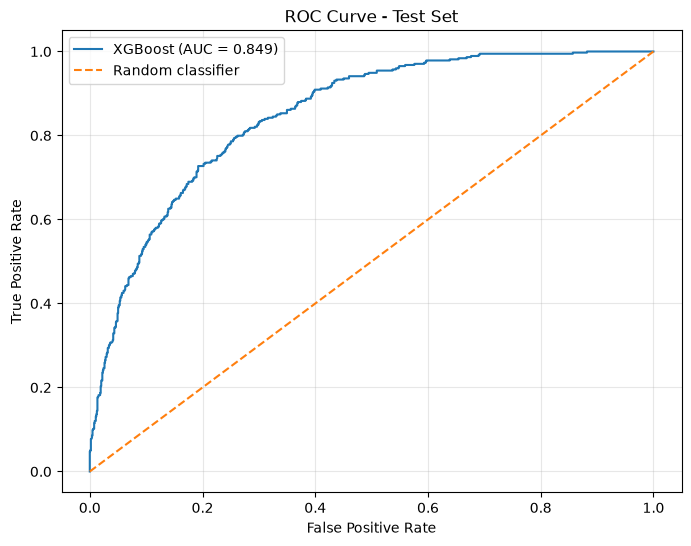

In [22]:
fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    y_test_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {test_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

El modelo obtiene un ROC-AUC de 0.849 sobre el conjunto de test.

Este resultado indica que el modelo presenta una buena capacidad de discriminación entre clientes que realizan churn y clientes que permanecen a lo largo de diferentes thresholds de clasificación.

Además, el valor obtenido en test es consistente con el rendimiento observado durante la fase de validación, lo que refuerza la estabilidad del comportamiento del modelo sobre datos no utilizados durante su desarrollo.

### 7.2 Curva Precision-Recall

La curva Precision-Recall muestra el trade-off entre precision y recall para diferentes thresholds.

Esta representación resulta especialmente relevante en este problema debido al desbalance de la variable objetivo y al interés específico en la detección de la clase positiva (`Churn = 1`).

Average Precision resume el rendimiento del modelo a lo largo de la curva Precision-Recall.

In [23]:
test_precision_curve, test_recall_curve, pr_thresholds = (
    precision_recall_curve(
        y_test,
        y_test_proba
    )
)

In [24]:
test_churn_rate = y_test.mean()

print(f"Churn rate:        {test_churn_rate:.4f}")
print(f"Average Precision: {test_average_precision:.4f}")

Churn rate:        0.2654
Average Precision: 0.6670


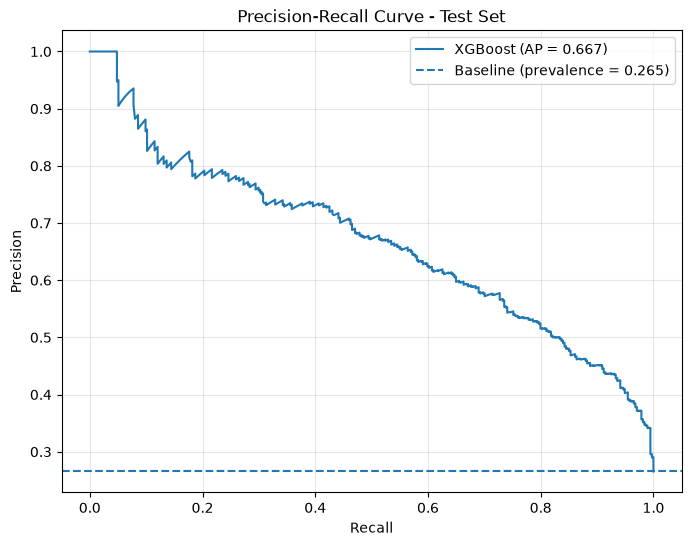

In [25]:
plt.figure(figsize=(8, 6))

plt.plot(
    test_recall_curve,
    test_precision_curve,
    label=f"XGBoost (AP = {test_average_precision:.3f})"
)

plt.axhline(
    y=test_churn_rate,
    linestyle="--",
    label=f"Baseline (prevalence = {test_churn_rate:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Test Set")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

El modelo obtiene un Average Precision de 0.667 sobre el conjunto de test.

Este valor es considerablemente superior a la prevalencia de la clase positiva en el conjunto de test, situada aproximadamente en 0.265. Por tanto, el modelo presenta una capacidad sustancialmente superior a la referencia sin capacidad de discriminación para priorizar clientes que realizan churn.

Además, el Average Precision obtenido en test es muy próximo al observado mediante validación cruzada durante el entrenamiento (aproximadamente 0.669), mostrando un comportamiento consistente sobre el conjunto reservado.

La curva también refleja el trade-off entre precision y recall: incrementar la proporción de churners detectados requiere aceptar una reducción de la precision, comportamiento que motivó la selección del threshold realizada durante la fase de entrenamiento.

## 8. Classification Report

Como resumen adicional de la evaluación, se analiza el classification report utilizando el threshold seleccionado de aproximadamente 0.315.

Este informe permite observar el comportamiento del modelo para ambas clases de forma independiente.

In [26]:
print(
    classification_report(
        y_test,
        y_test_pred_selected,
        target_names=["No Churn", "Churn"],
        digits=3
    )
)

              precision    recall  f1-score   support

    No Churn      0.898     0.764     0.826      1035
       Churn      0.538     0.759     0.630       374

    accuracy                          0.763      1409
   macro avg      0.718     0.762     0.728      1409
weighted avg      0.802     0.763     0.774      1409



### 8.1 Interpretación

Con el threshold seleccionado, el modelo obtiene un recall de 0.759 para la clase `Churn`, lo que significa que identifica aproximadamente el 76 % de los clientes que realmente realizan churn en el conjunto de test.

La precision para esta clase es de 0.538, indicando que aproximadamente el 54 % de los clientes clasificados como churners efectivamente pertenecen a esta clase. Esta menor precision es consecuencia del aumento de falsos positivos asociado a la reducción del threshold.

Para la clase `No Churn`, el modelo obtiene una precision de 0.898 y un recall de 0.764.

El F1-score de la clase `Churn` alcanza 0.630, mientras que la accuracy global del modelo es de 0.763.

Estos resultados son coherentes con el objetivo operativo establecido durante el entrenamiento: priorizar la detección de clientes con riesgo de churn, aceptando un mayor número de falsos positivos para reducir los falsos negativos.

## 9. Conclusiones

En este notebook se ha realizado la evaluación final del modelo XGBoost seleccionado durante la fase de entrenamiento, utilizando por primera vez el conjunto de test reservado.

El modelo obtiene un ROC-AUC de 0.849 y un Average Precision de 0.667. Este último resultado es muy próximo al Average Precision medio obtenido mediante validación cruzada durante el entrenamiento (aproximadamente 0.669), mostrando un comportamiento consistente sobre datos no utilizados durante el desarrollo del modelo.

Con el threshold por defecto de 0.5, el modelo alcanza un recall de 0.529 para la clase `Churn`. Al aplicar el threshold de aproximadamente 0.315 seleccionado previamente mediante predicciones out-of-fold sobre el conjunto de entrenamiento, el recall aumenta hasta 0.759.

En términos absolutos, el cambio de threshold permite identificar 284 de los 374 churners presentes en el conjunto de test, frente a los 198 detectados utilizando el threshold de 0.5. Esto supone detectar 86 churners adicionales y reducir los falsos negativos de 176 a 90.

Esta mejora en la detección tiene como contrapartida un aumento de los falsos positivos, que pasan de 99 a 244, y una reducción de la precision de 0.667 a 0.538.

Este comportamiento es coherente con el supuesto de negocio establecido en el proyecto, según el cual no detectar a un cliente que realiza churn tiene un impacto mayor que realizar una acción de retención sobre un cliente que finalmente permanece.

No obstante, el threshold seleccionado no debe interpretarse como económicamente óptimo. El dataset utilizado no contiene información sobre el valor económico de los clientes, el coste de las acciones de retención o el coste asociado a la pérdida de un cliente. En un escenario real, estas variables deberían incorporarse para optimizar el threshold en función del impacto económico esperado.

En conjunto, la evaluación final muestra un rendimiento consistente con las estimaciones obtenidas durante la fase de validación y confirma que el comportamiento esperado del threshold seleccionado se mantiene sobre el conjunto de test reservado.